In [45]:
import os.path as op
from glob import glob
import nibabel as nb

In [5]:
derivatives_dir = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/' 

In [39]:
xcpd_hcpya_dir = op.join(derivatives_dir, 
        'xcpd_output/hcpya_xcpd_4S156Parcels') 


In [13]:
nilearn_dir = op.join(derivatives_dir, 'connectivity-matrices/xcpd/correlation_ses')

In [14]:
nilearn_connectomes = glob(op.join(connectome_dir, '*', '*')) 

In [26]:
sub_list = []
_ = [sub_list.append(ii.split('/')[-2]) for ii in nilearn_connectomes] 

In [67]:
sub_list.sort()

In [69]:
sub_list[0]

'sub-102109'

In [95]:
xcpd_connectomes = glob(op.join(xcpd_hcpya_dir, 'sub-102109*pearsoncorrelation*nii')) 

In [96]:
xcpd_connectomes

['/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/xcpd_output/hcpya_xcpd_4S156Parcels/sub-102109_task-rest_dir-RL_run-1_space-fsLR_seg-4S156Parcels_den-91k_stat-pearsoncorrelation_boldmap.pconn.nii',
 '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/xcpd_output/hcpya_xcpd_4S156Parcels/sub-102109_task-rest_dir-RL_run-2_space-fsLR_seg-4S156Parcels_den-91k_stat-pearsoncorrelation_boldmap.pconn.nii',
 '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/xcpd_output/hcpya_xcpd_4S156Parcels/sub-102109_task-rest_dir-LR_run-2_space-fsLR_seg-4S156Parcels_den-91k_stat-pearsoncorrelation_boldmap.pconn.nii',
 '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/xcpd_output/hcpya_xcpd_4S156Parcels/sub-102109_task-rest_dir-LR_run-1_space-fsLR_seg-4S156Parcels_den-91k_stat-pearsoncorrelation_boldmap.pconn.nii']

In [81]:
import numpy as np

In [98]:
lr = nb.load(xcpd_connectomes[1]).get_fdata()

In [99]:
rl = nb.load(xcpd_connectomes[0]).get_fdata()

In [118]:
mean_xcpd = np.mean(np.array((lr, rl,
         nb.load(xcpd_connectomes[2]).get_fdata(), 
         nb.load(xcpd_connectomes[3]).get_fdata())), axis=0)[:100, :100] 

In [113]:
import matplotlib.pyplot as plt

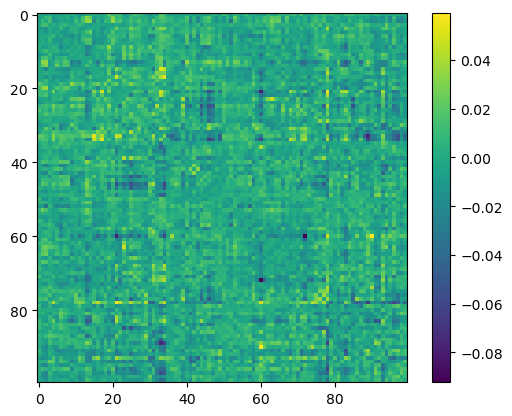

In [122]:
plt.imshow(nilearn_pkl['full_fc_matrix'] - mean_xcpd) 
plt.colorbar()

In [117]:
nilearn_pkl['full_fc_matrix']

array([[ 1.        ,  0.14951389,  0.26059195, ...,  0.13288279,
         0.41896293, -0.00474749],
       [ 0.14951389,  1.        ,  0.6978217 , ..., -0.3587656 ,
        -0.03421883, -0.3865857 ],
       [ 0.26059195,  0.6978217 ,  1.        , ..., -0.24473529,
         0.03408547, -0.27653533],
       ...,
       [ 0.13288279, -0.3587656 , -0.24473529, ...,  1.        ,
         0.34688774,  0.51078075],
       [ 0.41896293, -0.03421883,  0.03408547, ...,  0.34688774,
         1.        ,  0.4697593 ],
       [-0.00474749, -0.3865857 , -0.27653533, ...,  0.51078075,
         0.4697593 ,  1.        ]], shape=(100, 100), dtype=float32)

In [62]:
glob(op.join(nilearn_dir, 'sub-100206*')) 

[]

In [105]:
glob(op.join(nilearn_dir, 'sub-101206', '*pkl')) 

[]

In [109]:
import pickle

In [110]:
with open(nilearn_file[0], 'rb') as file: 
    nilearn_pkl = pickle.load(file) 

In [106]:
nilearn_file = glob(op.join(nilearn_dir, 'sub-102109', '*pkl')) 